# 02 - Basics: Load, Plot, Filter, And Group

This notebook shows the everyday eCAT rhythm: load a folder, inspect what came in, plot one CV, filter by metadata, make an overlay, group related traces, and save a small output.

The example data are the packaged Fe/PhOH CV text exports. Keep `reference mode` set to `"none"` here so the plots show the imported instrument potentials directly; reference shifting is introduced later in the notebook series.

## Import eCAT And Set Paths

This is the same full setup pattern from notebook 00. Later notebooks can shorten it, but this notebook keeps the paths explicit because it is the first everyday workflow example.

In [1]:
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

import ecat as e

DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

e.plotting_style("notebook")
print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Example data:", display_path(DATA_DIR))
print("Text files:", len(list(DATA_DIR.glob("*.txt"))))

eCAT version: 0.1.0b5
Example data: examples/data/fe_phoh_cv
Text files: 13


## Load The Example Folder With `get_data`

`get_data()` reads every supported text export in a folder and returns a list of eCAT objects. Here we keep reference correction off so the rest of the notebook focuses only on loading, plotting, filtering, and grouping.

In [2]:
cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "none",
});
cvs = e.filter(cvs, {"segments": 3}, {"print": False})

Searching recursively through:
 examples/data/fe_phoh_cv
13 supported text files found.

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆


,Gas,Compounds,Scan Window,Scan Rate,Segments
[0],Ar,,"[-1.2, 1]",100 mV/s,3
[1],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3
[2],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",100 mV/s,3
[3],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",25 mV/s,3
[4],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",500 mV/s,3
[5],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",1 V/s,3
[6],Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",50 mV/s,3
[7],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s,3
[8],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 100 mM PhOH","[-1.2, 1]",100 mV/s,3
[9],CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 560 mM PhOH","[-1.2, 1]",100 mV/s,3


## Inspect The Loaded Objects With `show_objects`

Before plotting or filtering, look at the object list. This table is the fastest check that filename metadata such as gas, scan rate, and compounds were parsed the way you expected.

If you are not sure which columns are available, ask `show_objects` for the column list first.

In [3]:
available_columns = e.show_objects(cvs, {"columns": "available"})
available_columns

['name',
 'subfolder',
 'type',
 'temperature',
 'electrode area',
 'electrode',
 'ir comp resistance',
 'ir uncomp resistance',
 'ir comp percent',
 'creation time',
 'timestamp',
 'solvent',
 'gas',
 'compounds',
 'scan rate',
 'segments',
 'exp type',
 'scan window']

In [4]:
e.show_objects(cvs, {
    "pretty print": True,
    "columns": ["name","gas", "scan rate", "compounds", "scan window"],
});

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆, Segments: 3, IR Comp Percent: 100 %


,Name,Gas,Compounds,Scan Window,Scan Rate
[0],MeCN_Ar_0.1MTBAPF6_-1.2_to_1V_100mVs,Ar,,"[-1.2, 1]",100 mV/s
[1],MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs,Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s
[2],MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_100mVs,Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",100 mV/s
[3],MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_25mVs,Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",25 mV/s
[4],MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_500mVs,Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",500 mV/s
[5],MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_1Vs,Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",1 V/s
[6],MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.7_to_1V_50mVs,Ar,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",50 mV/s
[7],MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs,CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s
[8],MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mMPhOH_-1.2_to_1V_100mVs,CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 100 mM PhOH","[-1.2, 1]",100 mV/s
[9],MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mMPhOH_-1.2_to_1V_100mVs,CO2,"3 mM Fc, 1 mM Fe-tpyPY2Me, 560 mM PhOH","[-1.2, 1]",100 mV/s


## Pick A Few Useful Subsets With `filter`

`filter()` returns a smaller list of objects whose metadata match your criteria. Use `logic: "AND"` when every criterion should be true at the same time.

In [5]:
ar = e.filter(cvs, {"gas": "Ar"}, {"print": False})
co2 = e.filter(cvs, {"gas": "CO2"}, {"print": False})
phoh_co2 = e.filter(cvs, {
    "gas": "CO2",
    "compounds": "PhOH",
}, {"logic": "AND", "print": False})

blank = e.filter(cvs, {
    "gas": "Ar",
    "compounds": ["Fc", "Fe-tpyPY2Me"],
}, {"logic": "AND", "mode": "exclude", "print": False})[0]

fe_ar = e.filter(cvs, {
    "gas": "Ar",
    "compounds": "Fe-tpyPY2Me",
}, {"logic": "AND", "print": False})

scan_series = e.filter(fe_ar, {
    "scan window": [-1.7, 1],
}, {"print": False})
scan_series = e.sort(scan_series, "scan rate", {"print": False})

print("Blank:", blank.name)
print("Ar traces:", len(ar))
print("CO2 traces:", len(co2))
print("CO2 + PhOH traces:", len(phoh_co2))
print("Fe Ar scan rates:", [obj.scan_rate for obj in scan_series])

Blank: MeCN_Ar_0.1MTBAPF6_-1.2_to_1V_100mVs
Ar traces: 7
CO2 traces: 5
CO2 + PhOH traces: 4
Fe Ar scan rates: [0.025, 0.05, 0.1, 0.5, 1.0]


## Plot One CV

A single object plots itself with `.plot()`. This is a good first visual check before making overlays.

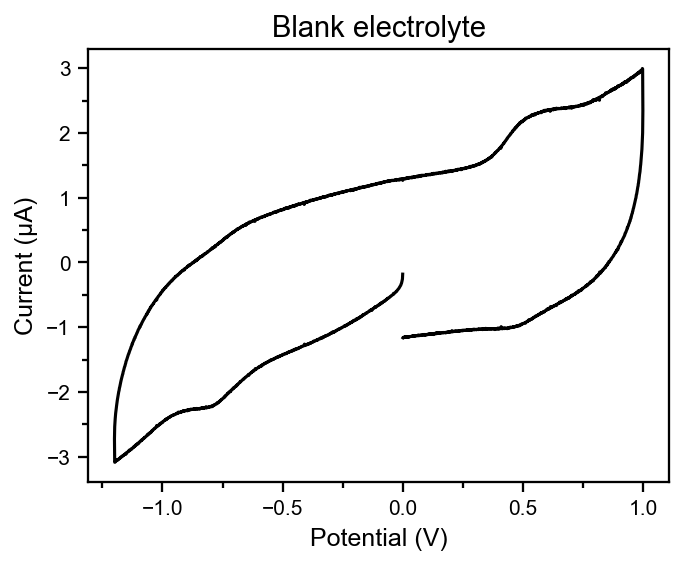

In [6]:
ax = blank.plot({
    "title": "Blank electrolyte",
})
# ax.figure.savefig(EXPORT_DIR / "blank_electrolyte.png", dpi=300, bbox_inches="tight")

## Overlay The Full CO2 Series With `multiplot`

`multiplot()` overlays a list of objects on one axes. Here the CO2 subset includes the full CO2 series from the packaged example folder.

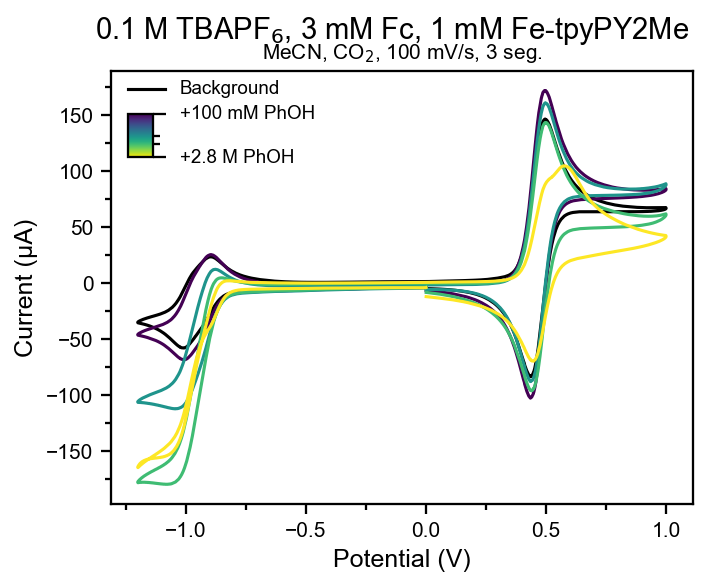

In [7]:
ax = e.multiplot(co2)
# ax.figure.savefig(EXPORT_DIR / "co2_series_overlay.png", dpi=300, bbox_inches="tight")

## Lightly Customize An Overlay

Notebook 02 keeps plotting simple: make an overlay, add readable labels, and adjust the axes if needed. Detailed plotting tools such as `trim()`, scale bars, gradients, colorbars, colormaps, and `multimultiplot()` are covered in notebook 04.

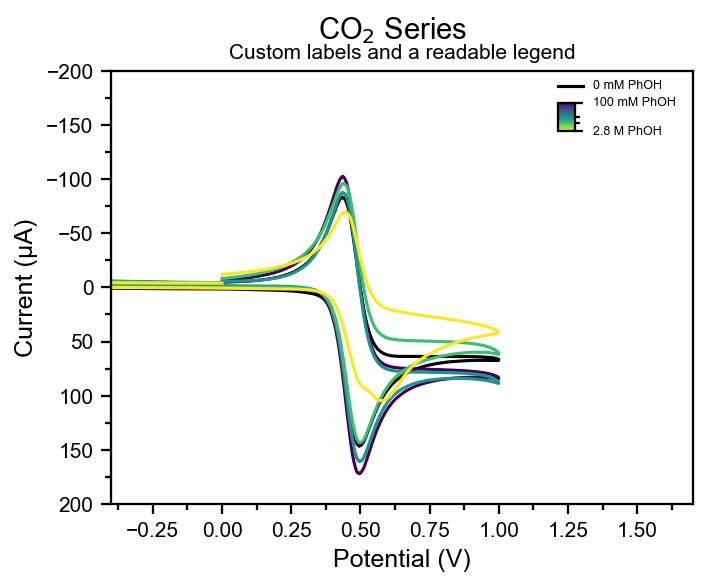

In [8]:
ax = e.multiplot(co2, {
    "print": False,
    "title": "CO$_2$ Series",
    "subtitle": "Custom labels and a readable legend",
    "labels": [
        "0 mM PhOH",
        "100 mM PhOH",
        "560 mM PhOH",
        "1 M PhOH",
        "2.8 M PhOH",
    ],
    "legend": True,
    "legend loc": "upper right",
    "x unit": "V",
    "y unit": "uA",
})

ax.set_xlim(-0.4, 1.7)
ax.set_ylim(200, -200);

## Sort And Group Objects

The same metadata keys are available for filtering, sorting, and grouping. `sort()` returns one ordered list, `group()` splits a list into groups, and `sort_and_group()` does those two steps together.

Sort keys can be a single key or a list of keys. Group keys can also be a single key or a list of keys.

In [9]:
available_filter_values = e.get_available_filter_values(cvs)
list(available_filter_values.keys())

['name',
 'subfolder',
 'compounds',
 'concentrations',
 'species',
 'type',
 'scan rate',
 'gas',
 'solvent',
 'ir comp resistance',
 'ir uncomp resistance',
 'ir comp percent',
 'scan window',
 'segments',
 'creation time',
 'timestamp',
 'applied potential',
 'sample interval',
 'run time',
 'final charge',
 'cathodic current',
 'anodic current',
 'cathodic time',
 'anodic time',
 'high potential limit',
 'low potential limit',
 'quiet time',
 'replicate']

## Print The Groups

Here we sort by two keys, then group by gas. `show_groups()` displays groups you have already created with `group()` or `sort_and_group()`.

In [10]:
sorted_cvs = e.sort(cvs, ["gas", "scan rate"], {"print": False})
groups = e.group(sorted_cvs, "gas", {"print": False})

e.show_groups(groups)

### Group 0 ###
[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, Segments: 3, IR Comp Percent: 100 %


,Compounds,Scan Window,Scan Rate
[0][0],"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",25 mV/s
[0][1],"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",50 mV/s
[0][2],,"[-1.2, 1]",100 mV/s
[0][3],"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.2, 1]",100 mV/s
[0][4],"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",100 mV/s
[0][5],"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",500 mV/s
[0][6],"3 mM Fc, 1 mM Fe-tpyPY2Me","[-1.7, 1]",1 V/s



### Group 1 ###
[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Compounds
[1][0],
[1][1],100 mM PhOH
[1][2],560 mM PhOH
[1][3],1 M PhOH
[1][4],2.8 M PhOH


## Save A Figure, CSV, And eCAT Workbook

Use `EXPORT_DIR` for notebook-generated files so outputs stay together. This example saves the full CO2 overlay, a lightweight CSV table, and a round-trip eCAT Excel workbook for the full CO2 + PhOH series.

With `data columns="all"`, referenced CVs export both the stored potential axis and the active referenced axis when a reference shift exists. Use an exact list such as `{"data columns": ["Potential vs Fc/Fc+", "Current"]}` when you want only specific exported columns.


Saved 4 echem objects to:
notebooks/_outputs/basic_co2_phoh_series.csv


Saved 4 echem objects to:
notebooks/_outputs/basic_co2_phoh_series.xlsx
Saved figure: notebooks/_outputs/basic_co2_overlay.png
Saved CSV: notebooks/_outputs/basic_co2_phoh_series.csv
Saved workbook: notebooks/_outputs/basic_co2_phoh_series.xlsx
Round-trip objects: 4 ['cv', 'cv', 'cv', 'cv']
[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Compounds
[0],100 mM PhOH
[1],560 mM PhOH
[2],1 M PhOH
[3],2.8 M PhOH


,object_id,sheet,class,x group,Name,Exp Type,Solvent,Gas,Compounds,Scan Window,...,Electrode Area,IR Comp Resistance,IR Uncomp Resistance,IR Comp Percent,Creation Time,Timestamp,Reference Shift,Reference Label,Reference Source,Software
0,obj_001,cv,cv,xg_001,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_100mM...,CV,MeCN,CO2,100 mM PhOH,"[-1.2, 1]",...,0,101.6,0,100,2026-06-08 12:16:55.175656,2026-05-07 16:22:24,,,,CH
1,obj_002,cv,cv,xg_001,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_560mM...,CV,MeCN,CO2,560 mM PhOH,"[-1.2, 1]",...,0,94.3,0,100,2026-06-08 12:16:55.196676,2026-05-07 16:37:02,,,,CH
2,obj_003,cv,cv,xg_001,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_1MPhO...,CV,MeCN,CO2,1 M PhOH,"[-1.2, 1]",...,0,108.1,0,100,2026-06-08 12:16:55.207502,2026-05-07 16:41:24,,,,CH
3,obj_004,cv,cv,xg_001,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_2.8MP...,CV,MeCN,CO2,2.8 M PhOH,"[-1.2, 1]",...,0,166.8,0,100,2026-06-08 12:16:55.221644,2026-05-07 17:15:37,,,,CH


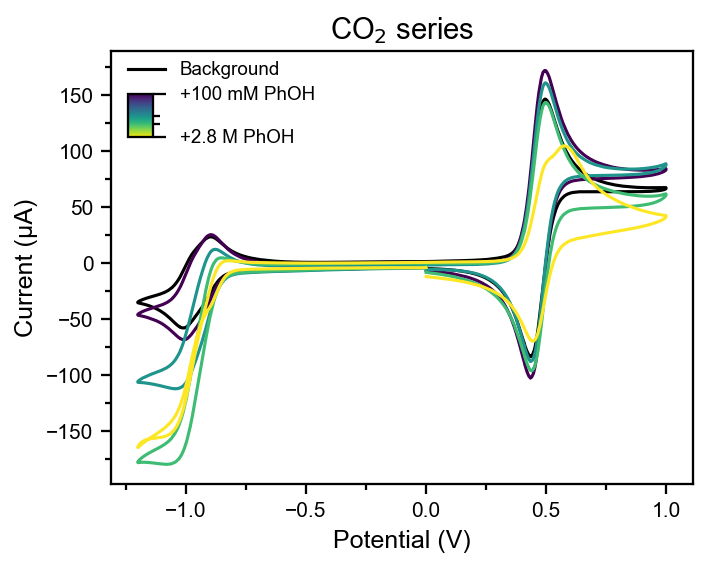

In [11]:
fig_path = EXPORT_DIR / "basic_co2_overlay.png"
ax = e.multiplot(co2, {
    "print": False,
    "title": "CO$_2$ series",
    "legend": True,
})
ax.figure.savefig(fig_path, dpi=300, bbox_inches="tight")

csv = e.save_data(phoh_co2, {
    "folder path": str(EXPORT_DIR),
    "file name": "basic_co2_phoh_series",
    "y unit": "uA",
})

workbook = e.save_data(phoh_co2, {
    "folder path": str(EXPORT_DIR),
    "file name": "basic_co2_phoh_series",
    "format": "xlsx",
    "metadata columns": ["reference source", "reference shift", "reference label"],
    "data columns": "all",
    "share x axes": True,
})

roundtrip = e.get_data_from_excel(EXPORT_DIR / "basic_co2_phoh_series.xlsx", {"print": False})

print("Saved figure:", display_path(fig_path))
print("Saved CSV:", display_path(EXPORT_DIR / "basic_co2_phoh_series.csv"))
print("Saved workbook:", display_path(EXPORT_DIR / "basic_co2_phoh_series.xlsx"))
print("Round-trip objects:", len(roundtrip), [type(obj).__name__ for obj in roundtrip])
e.show_objects(roundtrip, {"print": True})

workbook["manifest"].head()
